# Initial Data cleaning

In [18]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [19]:
# Get initial ball data
ball_data = pd.read_csv('data/ball-data.csv')

# Get initial match data
match_data = pd.read_csv('data/match-info.csv')
match_data = match_data.rename(columns={'match_number': 'ID'})
match_data.head()

# Get merged data
merged_data = pd.merge(ball_data, match_data, on='ID', how='left')
merged_data.head()

,ID,Innings,Overs,BallNumber,Batter,Bowler,NonStriker,ExtraType,BatsmanRun,ExtrasRun,...,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players
0,501208,1,0,1,S Sohal,Z Khan,S Dhawan,NaN,0,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
1,501208,1,0,2,S Sohal,Z Khan,S Dhawan,NaN,1,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
2,501208,1,0,3,S Dhawan,Z Khan,S Sohal,NaN,1,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
3,501208,1,0,4,S Sohal,Z Khan,S Dhawan,NaN,0,0,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."
4,501208,1,0,5,S Sohal,Z Khan,S Dhawan,wides,0,1,...,Royal Challengers Bangalore,field,Win,NaN,Deccan Chargers,DW Steyn,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,"S Sohal, S Dhawan, KC Sangakkara, B Chipli, JP...","MA Agarwal, TM Dilshan, Z Khan, V Kohli, AB de..."


In [20]:
merged_data.columns

Index(['ID', 'Innings', 'Overs', 'BallNumber', 'Batter', 'Bowler',
       'NonStriker', 'ExtraType', 'BatsmanRun', 'ExtrasRun', 'TotalRun',
       'IsWicketDelivery', 'PlayerOut', 'Kind', 'FieldersInvolved',
       'BattingTeam', 'team1', 'team2', 'match_date', 'toss_winner',
       'toss_decision', 'result', 'eliminator', 'winner', 'player_of_match',
       'venue', 'city', 'team1_players', 'team2_players'],
      dtype='str')

In [21]:
filtered_df = merged_data.drop(columns=['Batter', 'NonStriker', 'toss_winner', 'toss_decision', 'result', 'eliminator', 'venue', 'city', 'team1', 'team2', 'city', 'team1_players', 'team2_players', 'player_of_match', 'winner', 'BattingTeam'])
filtered_df.sort_values(by=['match_date', 'Innings', 'Overs', 'BallNumber'], inplace=True)
filtered_df = filtered_df.reset_index(drop=True)
filtered_df.head(40)

,ID,Innings,Overs,BallNumber,Bowler,ExtraType,BatsmanRun,ExtrasRun,TotalRun,IsWicketDelivery,PlayerOut,Kind,FieldersInvolved,match_date
0,335982,1,0,1,P Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,2008-04-18
1,335982,1,0,2,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
2,335982,1,0,3,P Kumar,wides,0,1,1,0,NaN,NaN,NaN,2008-04-18
3,335982,1,0,4,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
4,335982,1,0,5,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
5,335982,1,0,6,P Kumar,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
6,335982,1,0,7,P Kumar,legbyes,0,1,1,0,NaN,NaN,NaN,2008-04-18
7,335982,1,1,1,Z Khan,NaN,0,0,0,0,NaN,NaN,NaN,2008-04-18
8,335982,1,1,2,Z Khan,NaN,4,0,4,0,NaN,NaN,NaN,2008-04-18
9,335982,1,1,3,Z Khan,NaN,4,0,4,0,NaN,NaN,NaN,2008-04-18


## Note

- This data doesn't account for overthrows natively. I'm going to ignore this for now, but in the future, it would be better to scrape commentary data and find overthrows
- This dataset has unique names for unique players, albeit their naming scheme is a little inconsistent

In [22]:
filtered_df['BatsmanRun'].unique()

array([0, 4, 6, 1, 2, 5, 3])

In [23]:
filtered_df['ExtraType'].unique()
# filtered_df[filtered_df['ExtraType'] == 'byes,noballs'].head(20)

<StringArray>
[        'legbyes',               nan,           'wides',            'byes',
         'noballs',         'penalty',   'penalty,wides',    'byes,noballs',
 'legbyes,noballs']
Length: 9, dtype: str

In [24]:
filtered_df['Kind'].unique()

<StringArray>
[                    nan,                'caught',                'bowled',
               'run out',                   'lbw',          'retired hurt',
               'stumped',     'caught and bowled',            'hit wicket',
 'obstructing the field',           'retired out']
Length: 11, dtype: str

# Generating useful stats

For the model, we will use

- Sixes given up
- Wickets (bowled, lbw, c&b, stumped **MAYBE**)
- Wides
- penalty, wides (Only the wides part)
- No Balls (Only 1 per)
- Dot Balls **Maybe**

We will also need to know

- Year
- Economy Rate per year
- Total wickets taken

In [25]:
# Add a new column for year

filtered_df['Year'] = pd.to_datetime(filtered_df['match_date']).dt.year

In [73]:
# Loop through database and create aggregate stats for each bowler each year
rows_list = []

for year in filtered_df['Year'].unique():
    year_data = filtered_df[filtered_df['Year'] == year]
    for bowler in year_data['Bowler'].unique():
        bowler_data = year_data[year_data['Bowler'] == bowler]

        # Legal balls bowled
        total_balls = bowler_data.shape[0]
        total_balls -= bowler_data[bowler_data['ExtraType'].isin(['wides', 'noballs', 'penalty,wides', 'byes,noballs', 'legbyes,noballs', 'penalty'])].shape[0]
        if total_balls < 100:
            continue

        # Overs bowled
        overs_bowled = total_balls / 6

        # Regular runs
        batsman_runs = bowler_data['BatsmanRun'].sum()

        # Wide runs and penalty/wides
        wide_runs = bowler_data[bowler_data['ExtraType'].isin(['wides', 'noballs'])]['ExtrasRun'].sum()
        wide_runs += max(0, bowler_data[bowler_data['ExtraType'].isin(['penalty,wides'])]['ExtrasRun'].sum()-5)

        # No-ball runs and penalty/noballs
        noball_runs = bowler_data[bowler_data['ExtraType'].isin(['noballs'])]['ExtrasRun'].sum()
        noball_runs += len(bowler_data[bowler_data['ExtraType'].isin(['byes,noballs', 'legbyes,noballs'])]) 

        # Total runs given up
        total_runs = batsman_runs + wide_runs + noball_runs

        # Economy rate = total runs / (total balls / 6)
        economy = total_runs / (total_balls / 6) if total_balls > 0 else 0

        # Sixes given up
        sixes = bowler_data[bowler_data['BatsmanRun'] == 6].shape[0]

        # Dot balls bowled
        dot_balls = bowler_data[bowler_data['BatsmanRun'] == 0].shape[0]

        # Total wickets taken
        total_wickets = bowler_data[bowler_data['Kind'].isin(['bowled', 'caught', 'lbw', 'stumped', 'hit wicket', 'caught and bowled'])].shape[0]

        # Fielding Indpendent wickets (bowled, lbw, hit wicker, caught and bowled) [Maybe add stumped later]
        bowled_wickets = bowler_data[bowler_data['Kind'] == 'bowled'].shape[0]
        lbw_wickets = bowler_data[bowler_data['Kind'] == 'lbw'].shape[0]
        hit_wicket_wickets = bowler_data[bowler_data['Kind'] == 'hit wicket'].shape[0]
        caught_and_bowled_wickets = bowler_data[bowler_data['Kind'] == 'caught and bowled'].shape[0]
        stumped_wickets = bowler_data[bowler_data['Kind'] == 'stumped'].shape[0]

        rows_list.append({
            'Year': year,
            'Bowler': bowler,
            'Economy': economy,
            'TotalRuns': total_runs,
            'Overs': overs_bowled,
            'TotalBalls': total_balls,
            'TotalWickets': total_wickets,
            'Sixes': sixes,
            'Wides': wide_runs,
            'NoBalls': noball_runs,
            'DotBalls': dot_balls,
            'BowledWickets': bowled_wickets,
            'LbwWickets': lbw_wickets,
            'HitWicketWickets': hit_wicket_wickets,
            'CaughtAndBowledWickets': caught_and_bowled_wickets,
            'StumpedWickets': stumped_wickets,
        })

bowler_df = pd.DataFrame(rows_list)
bowler_df.sort_values(by=['Economy'], inplace=True)

bowler_df = bowler_df.reset_index(drop=True)
bowler_df.to_csv('data/bowler-stats.csv', index=False)
bowler_df.head(20)


,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,DotBalls,BowledWickets,LbwWickets,HitWicketWickets,CaughtAndBowledWickets,StumpedWickets
0,2009,M Muralitharan,5.220000,261,50.000000,300,14,6,4,0,154,3,4,0,0,2
1,2009,JP Duminy,5.314286,93,17.500000,105,4,3,7,0,49,0,0,0,0,1
2,2020,Rashid Khan,5.335052,345,64.666667,388,20,10,7,0,174,5,4,0,1,1
3,2012,L Balaji,5.400000,162,30.000000,180,11,3,11,0,99,3,0,0,0,0
4,2011,R Sharma,5.460000,273,50.000000,300,16,6,2,0,134,1,5,0,1,1
5,2013,SP Narine,5.468750,350,64.000000,384,22,8,3,0,186,2,3,0,3,2
6,2012,SP Narine,5.476056,324,59.166667,355,24,10,6,0,171,6,1,0,1,3
7,2009,A Singh,5.485714,96,17.500000,105,9,2,2,1,61,2,1,0,0,0
8,2022,SP Narine,5.571429,312,56.000000,336,9,12,7,0,148,2,2,0,1,0
9,2013,DW Steyn,5.796610,399,68.833333,413,19,7,22,0,231,8,1,0,0,0


# Training the model

In [94]:
recent_year_bowler_df = bowler_df[bowler_df['Year'] >= 2015]

X = recent_year_bowler_df[['Sixes', 'Wides', 'NoBalls', 'BowledWickets', 'LbwWickets', 'HitWicketWickets', 'CaughtAndBowledWickets', 'StumpedWickets']].div(recent_year_bowler_df['Overs'], axis=0)
y = recent_year_bowler_df['Economy']

fib_reg = LinearRegression().fit(X, y)

Text(0, 0.5, 'Actual Economy Rate')

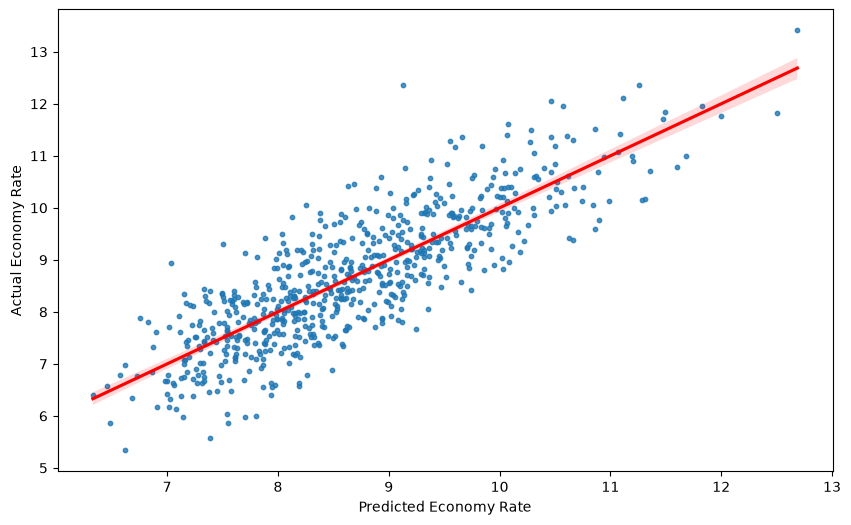

In [95]:
# Display regression
plt.figure(figsize=(10, 6))
sns.regplot(x=fib_reg.predict(X), y=y, scatter_kws={'s':10}, line_kws={'color': 'red'})
plt.xlabel('Predicted Economy Rate')
plt.ylabel('Actual Economy Rate')

In [96]:
# Print regression coefficients
fib_reg.coef_, fib_reg.intercept_ 

# Full training data regression coefficients and intercept:
# 5.1847644 ,  2.87836745,  2.50567393, -2.17970378, -0.82205995]),
#  np.float64(7.957189625273719))

(array([  5.76280152,   1.9969002 ,   2.86169915,  -2.5032706 ,
         -4.51658983,   1.42902186,  -1.40628447, -11.23541137]),
 np.float64(6.1821111900621535))

# See the meaning

In [ ]:
# Store FIB stats for each bowler in the dataframe
# fib_coefficients = np.array(fib_reg.coef_)
# fib_coefficients = np.insert(fib_coefficients, 0, fib_reg.intercept_)
fib_coefficients = np.array([6.1821, 5.7628, 1.9969, 2.8617, -2.5032, -4.5166, 1.4290, -1.4063, -11.2354])

for index, row in recent_year_bowler_df.iterrows():
    recent_year_bowler_df.at[index, 'raw_FIB'] = fib_coefficients[0] + fib_coefficients[1] * (row['Sixes'] / row['Overs']) + \
                                fib_coefficients[2] * (row['Wides'] / row['Overs']) + \
                                fib_coefficients[3] * (row['NoBalls'] / row['Overs']) + \
                                fib_coefficients[4] * (row['BowledWickets'] / row['Overs']) + \
                                fib_coefficients[5] * (row['LbwWickets'] / row['Overs']) + \
                                fib_coefficients[6] * (row['HitWicketWickets'] / row['Overs']) + \
                                fib_coefficients[7] * (row['CaughtAndBowledWickets'] / row['Overs']) + \
                                fib_coefficients[8] * (row['StumpedWickets'] / row['Overs'])

recent_year_bowler_df.sort_values(by=['raw_FIB'], inplace=True)
recent_year_bowler_df = recent_year_bowler_df.reset_index(drop=True)
recent_year_bowler_df.to_csv('data/bowler-stats-with-fib.csv', index=False)
recent_year_bowler_df.head(20)

,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,DotBalls,BowledWickets,LbwWickets,HitWicketWickets,CaughtAndBowledWickets,StumpedWickets,raw_FIB,FIB
0,2016,A Zampa,6.764706,115,17.000000,102,12,5,5,0,35,1,1,0,0,2,2.141388,6.570424
1,2017,P Negi,6.124352,197,32.166667,193,16,10,7,0,92,3,0,0,1,3,3.445858,6.518905
2,2017,Kuldeep Yadav,8.292683,340,41.000000,246,12,18,5,0,80,0,2,0,0,4,3.834298,7.354699
3,2018,S Gopal,7.612903,236,31.000000,186,11,15,2,0,70,0,0,0,3,3,4.101800,7.581228
4,2015,A Mishra,7.717842,310,40.166667,241,9,11,9,0,85,2,2,0,0,3,4.106177,6.611109
5,2025,MJ Santner,7.924051,313,39.500000,237,10,10,11,0,89,2,1,1,1,3,4.141275,6.601561
6,2020,RD Chahar,8.169811,433,53.000000,318,15,19,5,0,109,2,1,0,1,4,4.438832,6.950796
7,2019,S Lamichhane,9.130435,210,23.000000,138,8,13,0,0,47,0,2,0,1,2,4.617148,7.611360
8,2016,A Mishra,7.521739,346,46.000000,276,13,12,12,2,103,2,2,0,1,3,4.718789,7.230813
9,2017,S Nadeem,6.672897,119,17.833333,107,6,5,3,0,50,0,2,0,0,1,4.810293,6.501232


In [184]:
# Normalize FIB for each year based on economy mean and standard deviation
for year in recent_year_bowler_df['Year'].unique():
    year_data = recent_year_bowler_df[recent_year_bowler_df['Year'] == year]
    mean_economy = year_data['Economy'].mean()
    std_economy = year_data['Economy'].std()
    mean_fib = year_data['raw_FIB'].mean()
    std_fib = year_data['raw_FIB'].std()

    for index, row in year_data.iterrows():
        normalized_fib = (row['raw_FIB'] - mean_fib) / std_fib
        real_fib = normalized_fib * std_economy + mean_economy
        recent_year_bowler_df.at[index, 'FIB'] = real_fib

In [185]:
# Print average Economy and FIB for each year
average_stats = recent_year_bowler_df.groupby('Year').agg({'Economy': 'mean', 'raw_FIB': 'mean', 'FIB': 'mean'}).reset_index()
average_stats.head(20)

,Year,Economy,raw_FIB,FIB
0,2015,8.062274,7.706975,8.062274
1,2016,8.142694,7.616191,8.142694
2,2017,8.198062,7.673777,8.198062
3,2018,8.530913,8.182581,8.530913
4,2019,8.406933,8.125882,8.406933
5,2020,8.354425,8.186779,8.354425
6,2021,7.882633,7.975635,7.882633
7,2022,8.400043,8.552939,8.400043
8,2023,8.865536,8.606580,8.865536
9,2024,9.369667,9.096251,9.369667


In [186]:
# Print Standard Deviation of Economy and FIB for each year
std_stats = recent_year_bowler_df.groupby('Year').agg({'Economy': 'std', 'raw_FIB': 'std', 'FIB': 'std'}).reset_index()
std_stats.head(20)

,Year,Economy,raw_FIB,FIB
0,2015,0.939630,1.175216,0.939630
1,2016,0.791484,1.346474,0.791484
2,2017,1.086385,1.230171,1.086385
3,2018,1.166429,1.537166,1.166429
4,2019,1.267032,1.323715,1.267032
5,2020,1.274027,1.255151,1.274027
6,2021,1.061533,1.115305,1.061533
7,2022,1.162562,1.160013,1.162562
8,2023,1.004153,1.451562,1.004153
9,2024,1.266478,1.080802,1.266478


In [187]:
# Store Economy in next year for each bowler in a new dataframe
next_year_economy = []
for index, row in recent_year_bowler_df.iterrows():
    bowler = row['Bowler']
    year = row['Year']
    next_year_data = recent_year_bowler_df[(recent_year_bowler_df['Bowler'] == bowler) & (recent_year_bowler_df['Year'] == year + 1)]
    if not next_year_data.empty:
        new_row = row.to_dict()
        new_row['next_year_economy'] = next_year_data.iloc[0]['Economy']
        next_year_economy.append(new_row)

next_year_economy_df = pd.DataFrame(next_year_economy).reset_index(drop=True)
next_year_economy_df.head(20)

,Year,Bowler,Economy,TotalRuns,Overs,TotalBalls,TotalWickets,Sixes,Wides,NoBalls,DotBalls,BowledWickets,LbwWickets,HitWicketWickets,CaughtAndBowledWickets,StumpedWickets,raw_FIB,FIB,next_year_economy
0,2016,A Zampa,6.764706,115,17.000000,102,12,5,5,0,35,1,1,0,0,2,2.141388,4.924499,8.218487
1,2017,Kuldeep Yadav,8.292683,340,41.000000,246,12,18,5,0,80,0,2,0,0,4,3.834298,4.807353,8.142857
2,2018,S Gopal,7.612903,236,31.000000,186,11,15,2,0,70,0,0,0,3,3,4.101800,5.434345,7.250000
3,2015,A Mishra,7.717842,310,40.166667,241,9,11,9,0,85,2,2,0,0,3,4.106177,5.183299,7.521739
4,2020,RD Chahar,8.169811,433,53.000000,318,15,19,5,0,109,2,1,0,1,4,4.438832,4.550112,7.395349
5,2016,A Mishra,7.521739,346,46.000000,276,13,12,12,2,103,2,2,0,1,3,4.718789,6.439545,8.832618
6,2018,K Gowtham,7.800000,312,40.000000,240,11,9,4,0,94,4,0,0,1,2,4.881172,6.025746,8.300000
7,2023,YS Chahal,8.176656,432,52.833333,317,21,15,9,0,106,2,3,0,0,3,4.954687,6.339253,9.431034
8,2018,A Mishra,7.135135,264,37.000000,222,12,10,5,0,78,3,0,0,0,2,5.091076,6.185024,6.750000
9,2023,Ravi Bishnoi,7.782178,393,50.500000,303,16,16,9,2,104,1,3,0,1,3,5.147146,6.472390,8.770992


In [188]:
# Compare correlation between FIB and next year economy vs current year economy and next year economy
correlation_fib_next_year = next_year_economy_df['FIB'].corr(next_year_economy_df['next_year_economy'])
correlation_current_next_year = next_year_economy_df['Economy'].corr(next_year_economy_df['next_year_economy'])

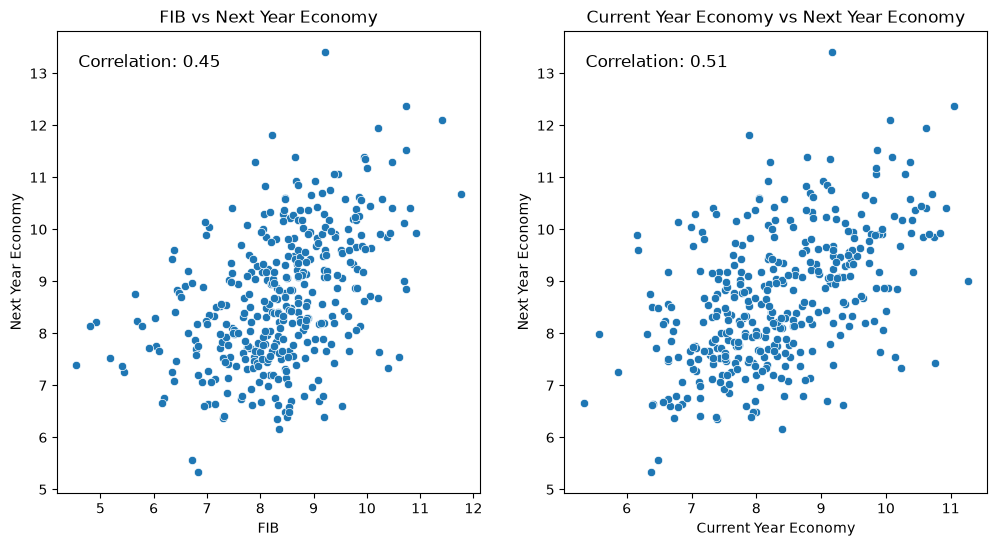

In [189]:
# Graph correlation between FIB and next year economy vs current year economy and next year economy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='FIB', y='next_year_economy', data=next_year_economy_df)
plt.title('FIB vs Next Year Economy')
plt.xlabel('FIB')
plt.ylabel('Next Year Economy')
plt.text(0.05, 0.95, f'Correlation: {correlation_fib_next_year:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Economy', y='next_year_economy', data=next_year_economy_df)
plt.title('Current Year Economy vs Next Year Economy')
plt.xlabel('Current Year Economy')
plt.ylabel('Next Year Economy')
plt.text(0.05, 0.95, f'Correlation: {correlation_current_next_year:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()